In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.image as mpimg
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Input, BatchNormalization
from tensorflow.keras.regularizers import l2, l1
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2, EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import warnings
import pickle
from pathlib import Path
warnings.filterwarnings('ignore')

In [2]:
image = []
target = []

p = Path("/crop")

for f in p.iterdir():
    if f.is_file():
            image.append(mpimg.imread(f))
            if ("TR__ovale" in f.name) or ("TE__ovale" in f.name):
                target.append("ovale")
            elif ("TR__rectangular" in f.name) or ("TE__rectangular" in f.name):
                target.append("rectangular")
            elif ("TR__square" in f.name) or ("TE__square" in f.name):
                target.append("square")
            elif ("TR__round" in f.name) or ("TE__round" in f.name):
                target.append("round")

data = {
        "image": image,
        "target": target
        }

df = pd.DataFrame(data)
df

,image,target
0,"[[[49, 52, 61], [49, 52, 61], [50, 53, 62], [5...",rectangular
1,"[[[90, 113, 183], [90, 113, 183], [90, 113, 18...",square
2,"[[[240, 241, 246], [240, 241, 246], [240, 241,...",round
3,"[[[191, 195, 196], [191, 195, 196], [191, 195,...",rectangular
4,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",ovale
...,...,...
1306,"[[[42, 55, 63], [42, 55, 63], [42, 55, 63], [4...",round
1307,"[[[242, 239, 246], [242, 239, 246], [242, 239,...",ovale
1308,"[[[182, 180, 191], [181, 179, 190], [179, 177,...",square
1309,"[[[181, 180, 188], [180, 179, 187], [180, 179,...",square


In [3]:
X_train, X_val_test, y_train, y_val_test = train_test_split(df["image"], df["target"], test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)
X_val = np.stack(X_val.to_numpy()).astype(np.uint8)
X_test = np.stack(X_test.to_numpy()).astype(np.uint8)
X_train = np.stack(X_train.to_numpy()).astype(np.uint8)

print('Train Size : ', X_train.shape, X_train.dtype)
print('Val Size   : ', X_val.shape, X_val.dtype)
print('Test Size  : ', X_test.shape, X_test.dtype)
print('Train Size : ', y_train.shape, y_train.dtype)
print('Val Size   : ', y_val.shape, y_val.dtype)
print('Test Size  : ', y_test.shape, y_test.dtype)

Train Size :  (786, 224, 224, 3) uint8
Val Size   :  (262, 224, 224, 3) uint8
Test Size  :  (263, 224, 224, 3) uint8
Train Size :  (786,) object
Val Size   :  (262,) object
Test Size  :  (263,) object


In [4]:
encoder_label = OrdinalEncoder(categories=[["ovale", "rectangular", "round", "square"]])
encoder_label.fit(y_train.to_frame())
y_train_encoded = encoder_label.transform(y_train.to_frame())
y_val_encoded = encoder_label.transform(y_val.to_frame())
y_test_encoded = encoder_label.transform(y_test.to_frame())

In [5]:
# Feature Scaling

X_train = X_train / 255.
X_val = X_val / 255.
X_test = X_test / 255.

In [6]:
# Clear Session
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

#Load MobileNetV2

base_model = MobileNetV2(weights = "imagenet", include_top = False, input_shape=(224, 224, 3))
base_model.trainable = False

data_augmentation = Sequential([tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    #tf.keras.layers.RandomZoom(0.05),
])

#CNN Iprovement
# Create Sequential API model

model = Sequential()
model.add(Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5),  input_shape=(224, 224,3)))
model.add(data_augmentation)
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3,3),padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3),padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-3)))
model.add(Dense(4, activation='softmax'))

# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(learning_rate=1e-3),
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,828 (1.17 MB)

 Trainable params: 304,932 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

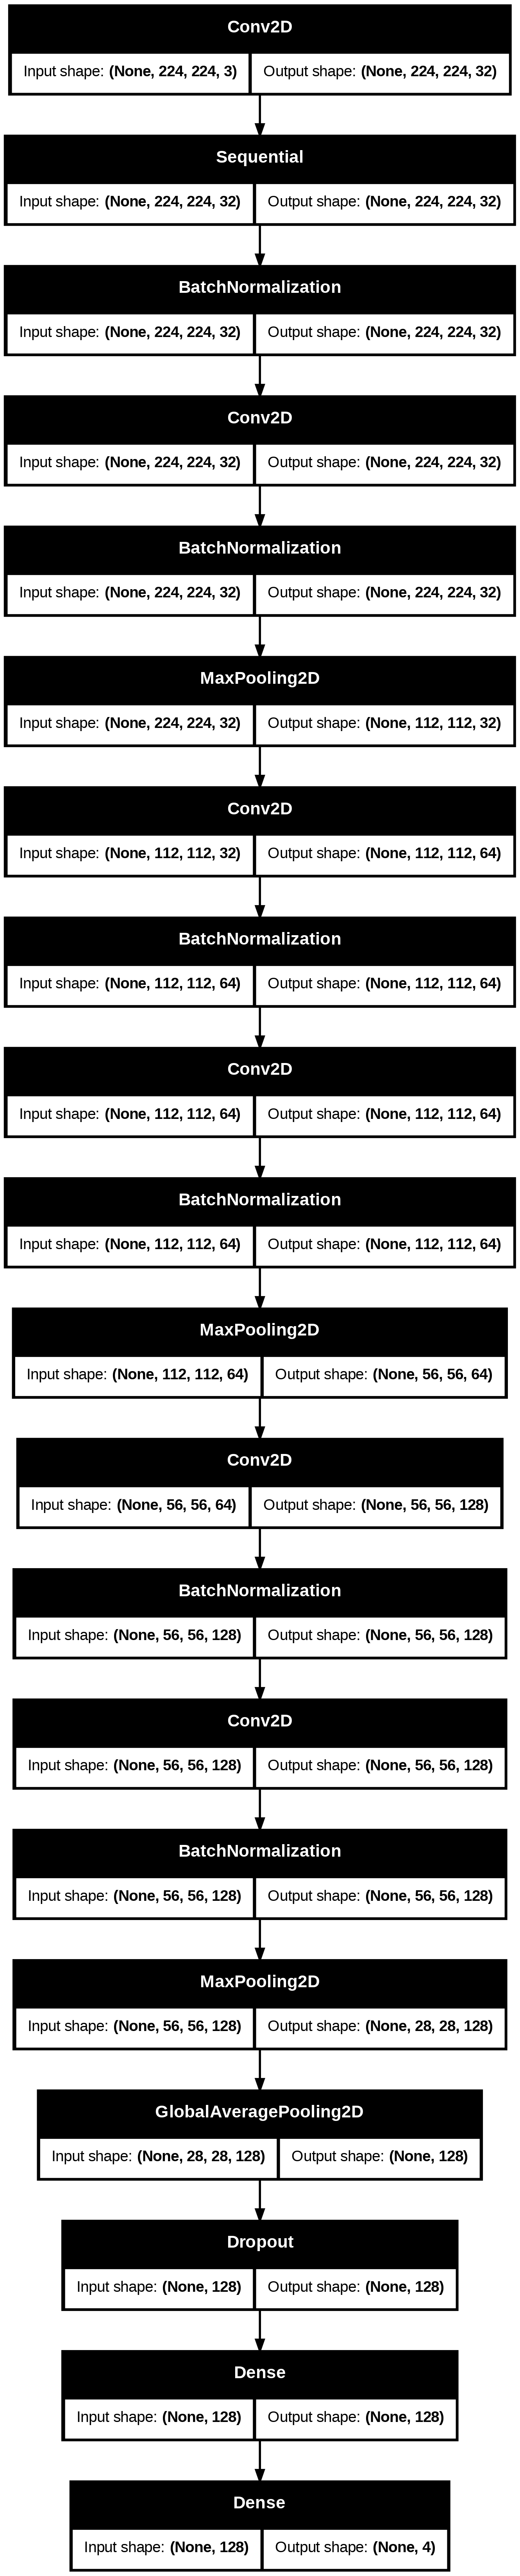

In [7]:
# Display model architecture
tf.keras.utils.plot_model(model, show_shapes=True)

In [8]:
# Train the Model

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    )
]

history_seq1 = model.fit(X_train, y_train_encoded, epochs=100, validation_data=(X_val, y_val_encoded))

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 408ms/step - accuracy: 0.3346 - loss: 1.5484 - val_accuracy: 0.2405 - val_loss: 1.5368
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.3422 - loss: 1.4811 - val_accuracy: 0.2328 - val_loss: 1.5639
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.3842 - loss: 1.4335 - val_accuracy: 0.2366 - val_loss: 1.6303
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.4198 - loss: 1.4030 - val_accuracy: 0.2366 - val_loss: 1.6715
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step - accuracy: 0.4262 - loss: 1.3920 - val_accuracy: 0.2786 - val_loss: 1.6000
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.4338 - loss: 1.3795 - val_accuracy: 0.2557 - val_loss: 1.7825
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 300ms/step - accuracy: 0.4478 - loss: 1.3571 - val_accuracy: 0.2519 - val_loss: 1.8229
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.4453 - loss: 1.3642 - val_acc

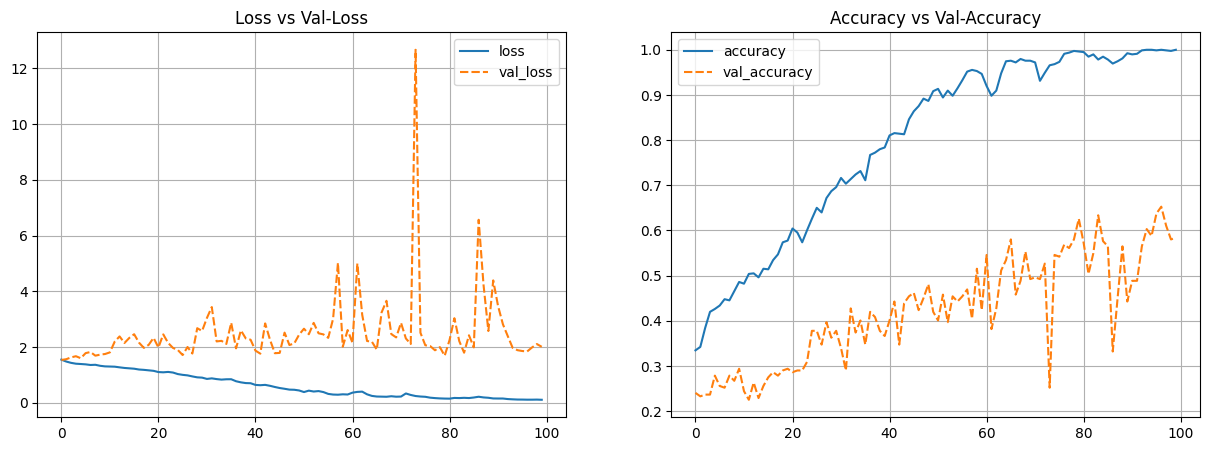

In [9]:
# Plot Training Results

history_seq_df =pd.concat([pd.DataFrame(history_seq1.history)
                           #,pd.DataFrame(history_seq2.history)
                           ], ignore_index=True)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_seq_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_seq_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

In [10]:
# Check the performance of test-set
class_names = ["ovale", "rectangular", "round", "square"]
# Get the probability
y_pred_proba = model.predict(X_test)

# Get class with maximum probability
y_pred_test = np.argmax(y_pred_proba, axis=-1)

# Display Classification Report
print(classification_report(y_test_encoded, y_pred_test, target_names=np.array(class_names)))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
              precision    recall  f1-score   support

       ovale       0.69      0.64      0.66        83
 rectangular       0.45      0.69      0.55        58
       round       0.80      0.59      0.68        70
      square       0.53      0.48      0.51        52

    accuracy                           0.60       263
   macro avg       0.62      0.60      0.60       263
weighted avg       0.64      0.60      0.61       263



In [11]:
# Model is saved to desired folder
with open("/pickle/model.pkl", 'wb') as file_1:
  pickle.dump(model, file_1)